# Gierer–Meinhardt Analysis

In this notebook, we study the Gierer–Meinhardt reaction–diffusion system from the perspective of diffusion-driven instability.

The aim is to understand when a homogeneous steady state becomes unstable after diffusion is introduced, leading to the formation of Turing patterns. This model is another classical activator–inhibitor system and provides a useful comparison with the Schnakenberg and substrate–inhibitor models.

In particular, we:
- visualise the parameter regions where Turing instability can occur,
- compute the homogeneous steady state,
- examine the nullclines and fixed point,
- analyse the Jacobian and eigenvalues,
- study the dispersion relation as a function of spatial wavenumber,
- and compare the effect of taking $a=0.1$ and $a=-0.1$.

We begin with the parameter-space picture before focusing on representative parameter choices.

In [1]:
import sys
import os

sys.path.append(os.path.abspath("../.."))

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

from src.analysis_tools.derivatives import gierer_meinhardt_derivatives
from src.analysis_tools.steady_states import gierer_meinhardt_steady_state
from src.analysis_tools.turing import (
    compute_turing_mask,
    trace_det,
    critical_diffusion_ratio,
)
from src.visualiser import plot_phase_plane, plot_turing_relation

## 1. Parameter-space exploration

Before fixing a particular choice of parameters, we first examine where Turing instability is possible in the $(a,b)$-parameter space.

For the Gierer–Meinhardt model,

$$
f(u,v)=a-bu+\frac{u^2}{v}, 
\qquad 
g(u,v)=u^2-v.
$$

The homogeneous steady state is

$$
u_0=\frac{a+1}{b}, 
\qquad 
v_0=u_0^2.
$$

At each point $(a,b)$, we evaluate the Jacobian at the steady state and check whether the system is stable without diffusion but unstable for at least one spatial mode after diffusion is introduced.

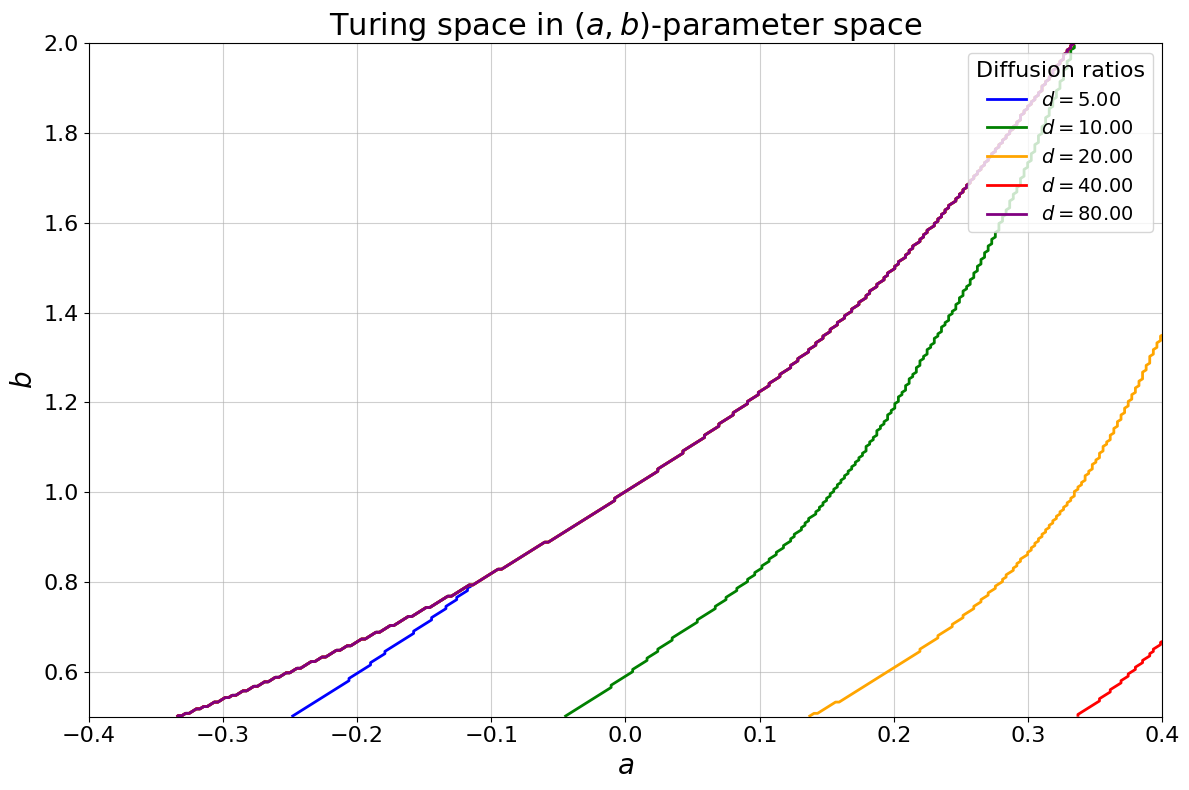

In [2]:
# Parameter grid
a_vals = np.linspace(-0.4, 0.4, 300)
b_vals = np.linspace(0.5, 2.0, 300)
A, B = np.meshgrid(a_vals, b_vals)

# Diffusion ratios
d_values = [5, 10, 20, 40, 80]
colors = ["blue", "green", "orange", "red", "purple"]

# Wavenumber range
k2_vals = np.linspace(0.01, 10, 100)

def gm_derivative_wrapper(a, b):
    u0, v0 = gierer_meinhardt_steady_state(a, b)
    return gierer_meinhardt_derivatives(a, b, u0, v0)

plt.figure(figsize=(12, 8))
legend_elements = []

for d_val, color in zip(d_values, colors):
    mask = compute_turing_mask(A, B, d_val, k2_vals, gm_derivative_wrapper)

    plt.contour(A, B, mask, levels=[0.5], colors=color, linewidths=2)

    legend_elements.append(
        Line2D([0], [0], color=color, lw=2, label=fr"$d = {d_val:.2f}$")
    )

plt.xlabel(r"$a$", fontsize=20)
plt.ylabel(r"$b$", fontsize=20)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.grid(True, alpha=0.6)
plt.title(r"Turing space in $(a,b)$-parameter space", fontsize=22)

plt.legend(
    handles=legend_elements,
    title="Diffusion ratios",
    fontsize=14,
    title_fontsize=16,
    loc="upper right",
)

plt.tight_layout()
plt.show()

## 2. Choosing representative parameter sets

We now consider two representative choices,

$$
a = 0.1, \qquad b=1,
$$

and

$$
a = -0.1, \qquad b=1.
$$

These allow us to compare how changing the sign of $a$ affects the homogeneous steady state and the associated instability structure.

In [3]:
gamma = 2.0
b = 1.0
d = 20.0

a_cases = [0.1, -0.1]

for a in a_cases:
    u0, v0 = gierer_meinhardt_steady_state(a, b)
    print(f"a = {a:.2f}, b = {b:.2f}")
    print(f"u0 = {u0:.4f}, v0 = {v0:.4f}")
    print()

a = 0.10, b = 1.00
u0 = 1.1000, v0 = 1.2100

a = -0.10, b = 1.00
u0 = 0.9000, v0 = 0.8100



## 3. Nullclines and fixed points

Before introducing diffusion, we examine the reaction kinetics of the spatially homogeneous system.

The nullclines are defined by

$$
f(u,v)=0,
\qquad
g(u,v)=0.
$$

For the Gierer–Meinhardt model, the $g(u,v)=0$ nullcline is simply

$$
v=u^2.
$$

We compare the phase-plane structure for a=0.1 and a=-0.1.

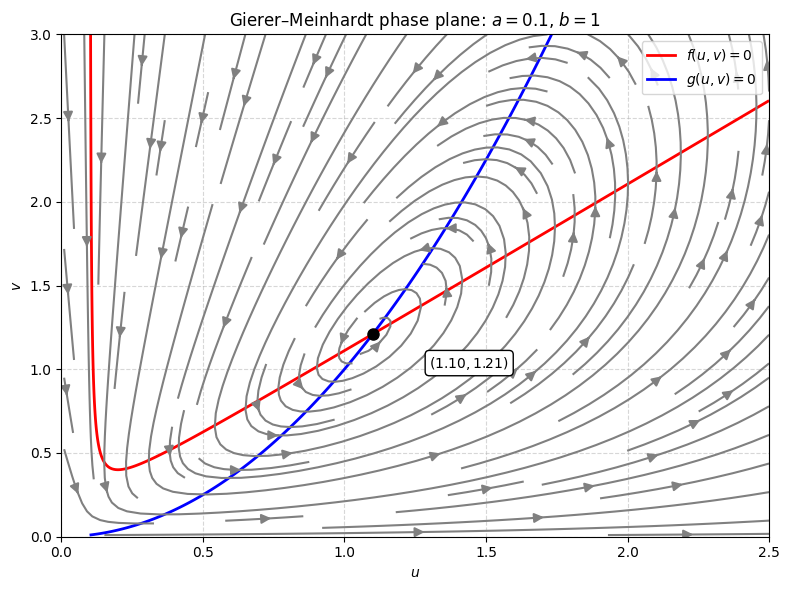

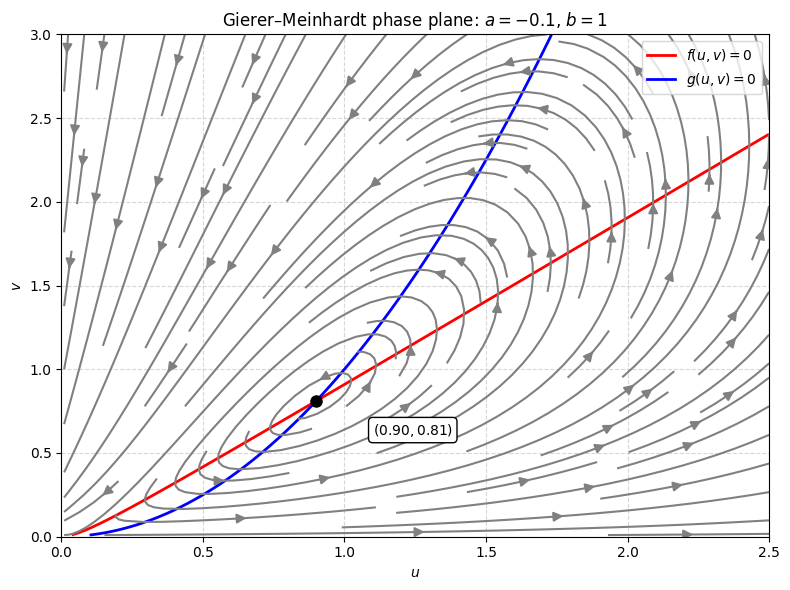

In [4]:
for a in a_cases:
    u0, v0 = gierer_meinhardt_steady_state(a, b)

    def f_phase(u, v, a=a):
        return a - b * u + (u**2) / v

    def g_phase(u, v):
        return u**2 - v

    plot_phase_plane(
        f=f_phase,
        g=g_phase,
        u0=u0,
        v0=v0,
        u_range=(0.01, 2.5),
        v_range=(0.01, 3.0),
        title=fr"Gierer–Meinhardt phase plane: $a={a}$, $b=1$"
    )

## 4. Jacobian and local stability

We now linearise the reaction terms around the homogeneous steady state. The Jacobian is

$$
J=
\begin{pmatrix}
f_u & f_v \\
g_u & g_v
\end{pmatrix}.
$$

Stability in the absence of diffusion requires

$$
\operatorname{tr}(J)<0,
\qquad
\det(J)>0.
$$

In [5]:
for a in a_cases:
    u0, v0 = gierer_meinhardt_steady_state(a, b)
    fu, fv, gu, gv = gierer_meinhardt_derivatives(a, b, u0, v0)

    J = np.array([
        [fu, fv],
        [gu, gv]
    ])

    trJ, detJ = trace_det(fu, fv, gu, gv)
    eigvals = np.linalg.eigvals(J)

    print(f"Case: a = {a:.2f}, b = {b:.2f}")
    print("Jacobian:")
    print(J)

    print("\nTrace and determinant:")
    print(f"tr(J)  = {trJ:.4f}")
    print(f"det(J) = {detJ:.4f}")

    print("\nEigenvalues:")
    for i, eig in enumerate(eigvals, start=1):
        print(f"lambda_{i} = {eig:.4f}")

    print("\nStable without diffusion?")
    print(trJ < 0 and detJ > 0)
    print("-" * 50)

Case: a = 0.10, b = 1.00
Jacobian:
[[ 0.8181818  -0.82644627]
 [ 2.2        -1.        ]]

Trace and determinant:
tr(J)  = -0.1818
det(J) = 1.0000

Eigenvalues:
lambda_1 = -0.0909+0.9959j
lambda_2 = -0.0909-0.9959j

Stable without diffusion?
True
--------------------------------------------------
Case: a = -0.10, b = 1.00
Jacobian:
[[ 1.22222219 -1.23456787]
 [ 1.8        -1.        ]]

Trace and determinant:
tr(J)  = 0.2222
det(J) = 1.0000

Eigenvalues:
lambda_1 = 0.1111+0.9938j
lambda_2 = 0.1111-0.9938j

Stable without diffusion?
False
--------------------------------------------------


## 5. Dispersion relation and unstable modes

To understand which spatial modes grow after diffusion is introduced, we study the dispersion relation.

When $h(k^2)<0$, the dominant eigenvalue becomes positive for a band of spatial modes, indicating diffusion-driven instability.

We compare values of the diffusion ratio below, at, and above the critical threshold $d_c$ for both choices of $a$.

Critical diffusion ratio: dc = 8.2384


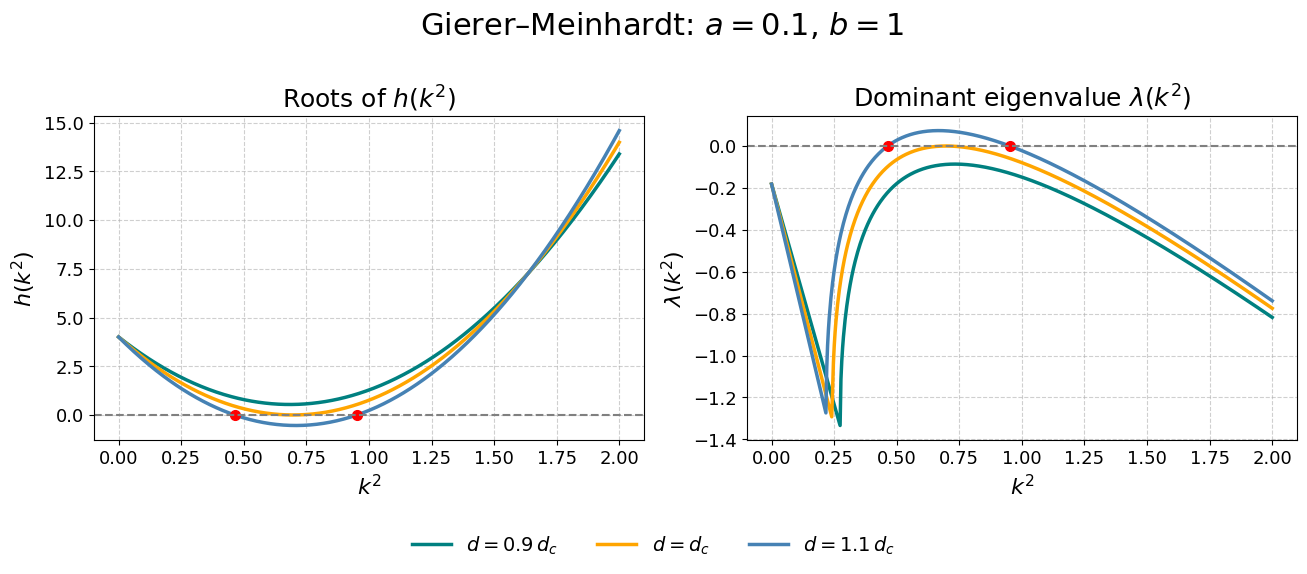

In [8]:
a = 0.1
b = 1.0
gamma = 2.0

u0, v0 = gierer_meinhardt_steady_state(a, b)
fu, fv, gu, gv = gierer_meinhardt_derivatives(a, b, u0, v0)

dc = critical_diffusion_ratio(fu, fv, gu, gv)

print(f"Critical diffusion ratio: dc = {dc:.4f}")

d_vals = [0.9 * dc, dc, 1.1 * dc]
labels = [r"$d = 0.9\,d_c$", r"$d = d_c$", r"$d = 1.1\,d_c$"]
colors = ["teal", "orange", "steelblue"]

k2_vals = np.linspace(0, 2.0, 600)

plot_turing_relation(
    k2_vals=k2_vals,
    fu=fu,
    fv=fv,
    gu=gu,
    gv=gv,
    gamma=gamma,
    d_vals=d_vals,
    labels=labels,
    colors=colors,
    title=fr"Gierer–Meinhardt: $a={a}$, $b=1$"
)

## 6. Conclusion

For the Gierer–Meinhardt system, we observe two qualitatively different behaviours depending on the parameter $a$.

For $a=0.1$, the homogeneous steady state satisfies
\[
$\operatorname{tr}(J) < 0, \qquad \det(J) > 0$,
\]
so it is stable in the absence of diffusion. The dispersion relation shows that for sufficiently large diffusion ratio $d$, there exists a band of spatial modes with positive growth rate. This confirms the presence of a diffusion-driven (Turing) instability.

For $a=-0.1$, the trace of the Jacobian is positive, so the steady state is already unstable in the reaction-only system. In this case, instability is not induced by diffusion, and therefore does not correspond to a Turing mechanism.

Overall, the Gierer–Meinhardt model exhibits classical Turing behaviour for appropriate parameter choices, with instability arising from the interaction between reaction kinetics and differential diffusion.